# Análisis Exploratorio de Datos (EDA)
En este cuaderno realizaremos el análisis exploratorio de datos de nuestro conjunto de datos de viviendas de California.
Este paso es fundamental en cualquier flujo de MLOps para comprender la distribución de los datos, detectar valores atípicos y entender las correlaciones entre características.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficos
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Cargar los datos
data_path = '1553768847-housing.csv'
df = pd.read_csv(data_path)

# Mostrar las primeras filas
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200
5,-122.25,37.85,52,919,213.0,413,193,4.0368,NEAR BAY,269700
6,-122.25,37.84,52,2535,489.0,1094,514,3.6591,NEAR BAY,299200
7,-122.25,37.84,52,3104,687.0,1157,647,3.1200,NEAR BAY,241400
8,-122.26,37.84,42,2555,665.0,1206,595,2.0804,NEAR BAY,226700
9,-122.25,37.84,52,3549,707.0,1551,714,3.6912,NEAR BAY,261100


## 1. Información General del Dataset
Revisaremos la estructura, tipos de datos y la presencia de valores nulos.

In [17]:
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas\n")
df.info()

Dimensiones del dataset: 20640 filas x 10 columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


## 2. Estadísticas Descriptivas
Observaremos las principales métricas de nuestras variables numéricas.

In [18]:
df.describe().T.style.background_gradient(cmap='Blues', axis=1).format('{:,.2f}')

,count,mean,std,min,25%,50%,75%,max
longitude,"20,640.00",-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31
latitude,"20,640.00",35.63,2.14,32.54,33.93,34.26,37.71,41.95
housing_median_age,"20,640.00",28.64,12.59,1.00,18.00,29.00,37.00,52.00
total_rooms,"20,640.00","2,635.76","2,181.62",2.00,"1,447.75","2,127.00","3,148.00","39,320.00"
total_bedrooms,"20,433.00",537.87,421.39,1.00,296.00,435.00,647.00,"6,445.00"
population,"20,640.00","1,425.48","1,132.46",3.00,787.00,"1,166.00","1,725.00","35,682.00"
households,"20,640.00",499.54,382.33,1.00,280.00,409.00,605.00,"6,082.00"
median_income,"20,640.00",3.87,1.90,0.50,2.56,3.53,4.74,15.00
median_house_value,"20,640.00","206,855.82","115,395.62","14,999.00","119,600.00","179,700.00","264,725.00","500,001.00"


## 3. Análisis de Valores Nulos
Identificamos los valores faltantes para decidir estrategias de imputación.

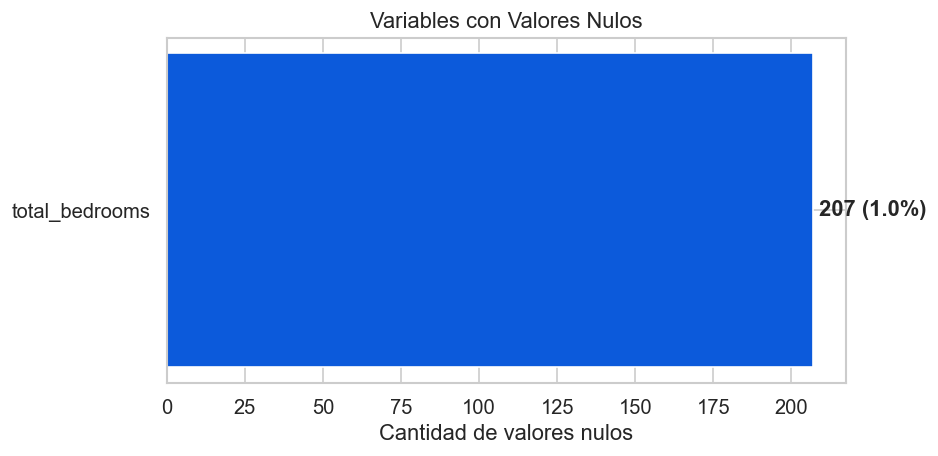


Resumen de nulos:
                Nulos  % del Total
total_bedrooms    207          1.0


In [19]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100).round(2)
null_df = pd.DataFrame({'Nulos': null_counts, '% del Total': null_pct})
null_df = null_df[null_df['Nulos'] > 0].sort_values('Nulos', ascending=False)

if len(null_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(null_df.index, null_df['Nulos'], color='#0C5ADB')
    ax.set_xlabel('Cantidad de valores nulos')
    ax.set_title('Variables con Valores Nulos')
    for i, (v, p) in enumerate(zip(null_df['Nulos'], null_df['% del Total'])):
        ax.text(v + 2, i, f'{v} ({p}%)', va='center', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("✅ No hay valores nulos en el dataset")

print("\nResumen de nulos:")
print(null_df if len(null_df) > 0 else "Sin valores nulos")

## 4. Distribución de la Variable Objetivo (median_house_value)
Es importante ver cómo se distribuye el valor medio de las casas para entender la variable que queremos predecir.

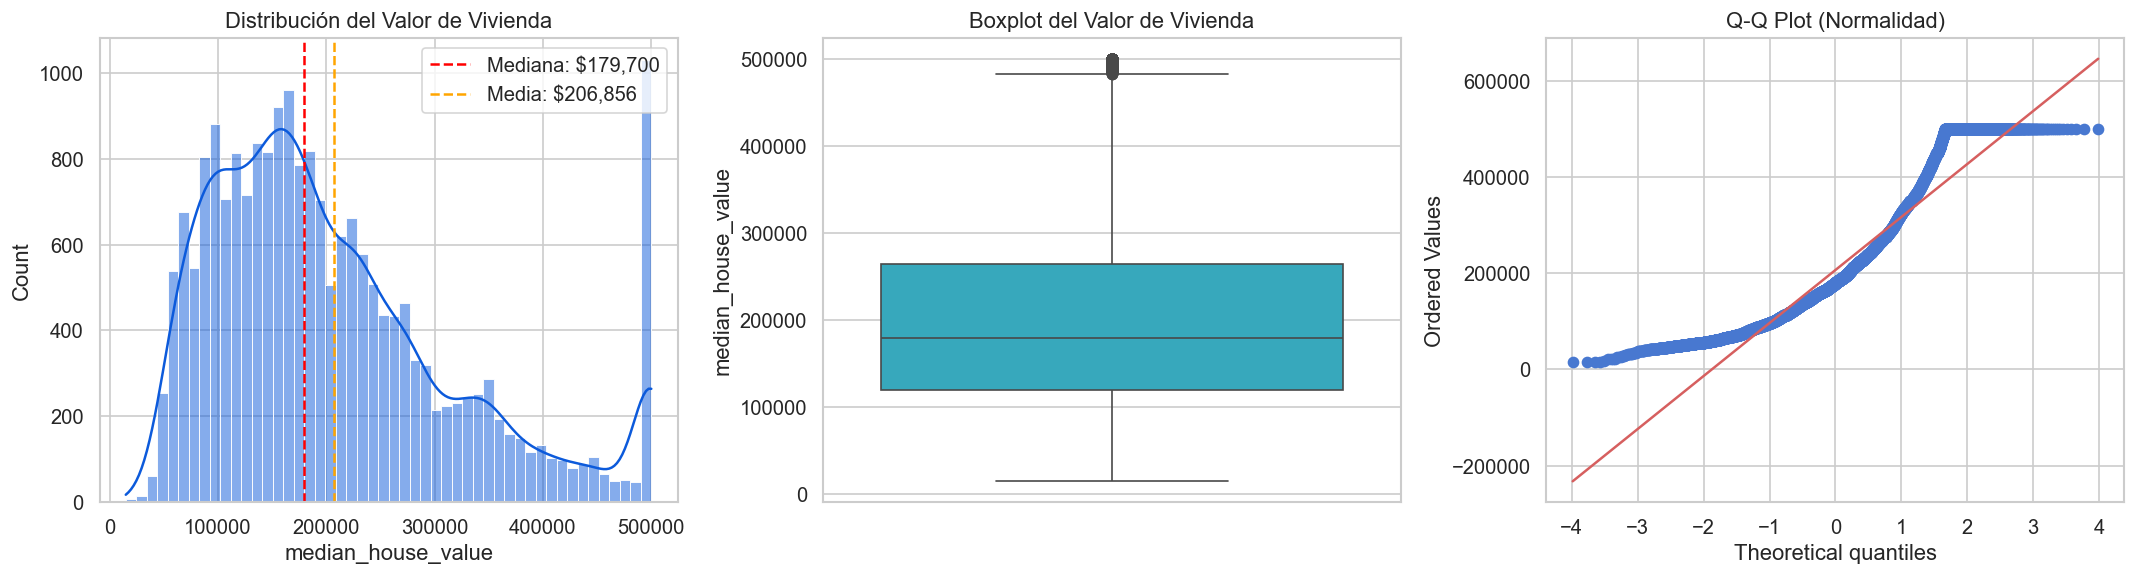

📊 Estadísticas de la variable objetivo:
  Media:    $  206,855.82
  Mediana:  $  179,700.00
  Std:      $  115,395.62
  Asimetría:    0.978
  Curtosis:     0.328
  Valores en el techo ($500,001): 965 (4.7%)


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma con KDE
sns.histplot(df['median_house_value'], kde=True, bins=50, color='#0C5ADB', ax=axes[0])
axes[0].set_title('Distribución del Valor de Vivienda')
axes[0].axvline(df['median_house_value'].median(), color='red', linestyle='--', label=f'Mediana: ${df["median_house_value"].median():,.0f}')
axes[0].axvline(df['median_house_value'].mean(), color='orange', linestyle='--', label=f'Media: ${df["median_house_value"].mean():,.0f}')
axes[0].legend()

# Boxplot
sns.boxplot(y=df['median_house_value'], color='#21B8D2', ax=axes[1])
axes[1].set_title('Boxplot del Valor de Vivienda')

# QQ-Plot (normalidad)
from scipy import stats
stats.probplot(df['median_house_value'], plot=axes[2])
axes[2].set_title('Q-Q Plot (Normalidad)')

plt.tight_layout()
plt.show()

print(f"📊 Estadísticas de la variable objetivo:")
print(f"  Media:    ${df['median_house_value'].mean():>12,.2f}")
print(f"  Mediana:  ${df['median_house_value'].median():>12,.2f}")
print(f"  Std:      ${df['median_house_value'].std():>12,.2f}")
print(f"  Asimetría: {df['median_house_value'].skew():>8.3f}")
print(f"  Curtosis:  {df['median_house_value'].kurtosis():>8.3f}")
print(f"  Valores en el techo ($500,001): {(df['median_house_value'] == 500001).sum()} ({(df['median_house_value'] == 500001).mean()*100:.1f}%)")

## 5. Distribución de Todas las Variables Numéricas
Visualizamos la distribución de cada feature numérica con histogramas y boxplots.

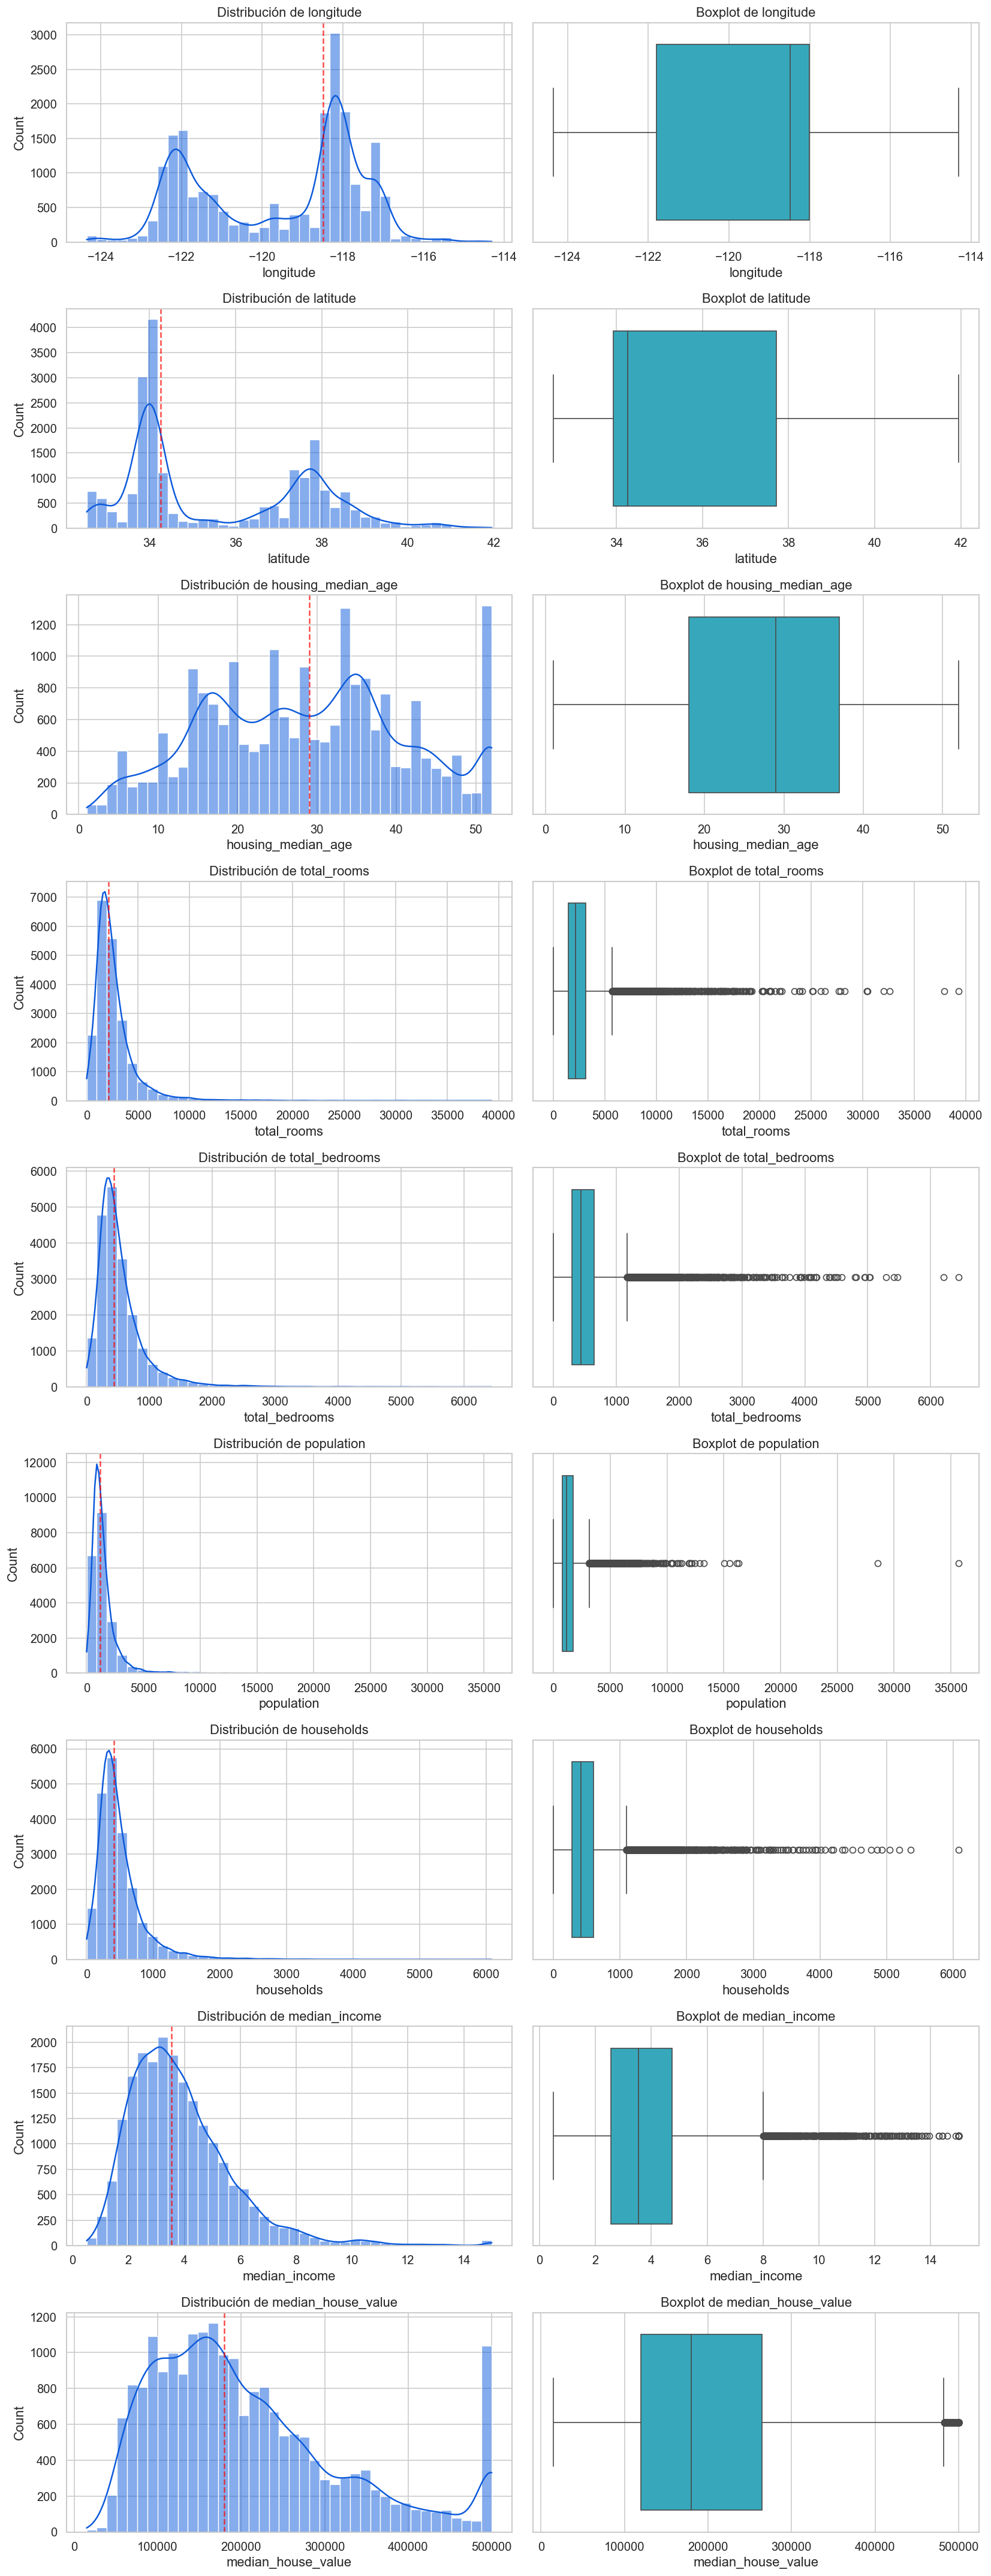

In [21]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
n = len(num_cols)
fig, axes = plt.subplots(n, 2, figsize=(14, 4 * n))

for i, col in enumerate(num_cols):
    # Histograma
    sns.histplot(df[col], kde=True, bins=40, color='#0C5ADB', ax=axes[i, 0])
    axes[i, 0].set_title(f'Distribución de {col}')
    axes[i, 0].axvline(df[col].median(), color='red', linestyle='--', alpha=0.7)

    # Boxplot
    sns.boxplot(x=df[col], color='#21B8D2', ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

## 6. Análisis de Asimetría (Skewness)
La asimetría nos indica si las variables están sesgadas, lo cual puede afectar el rendimiento de algunos modelos.

Asimetría (Skewness) de variables numéricas:

  ⚠️                population:    4.936
  ⚠️               total_rooms:    4.147
  ⚠️            total_bedrooms:    3.460
  ⚠️                households:    3.410
  ⚠️             median_income:    1.647
  ✅        median_house_value:    0.978
  ✅                  latitude:    0.466
  ✅        housing_median_age:    0.060
  ✅                 longitude:   -0.298


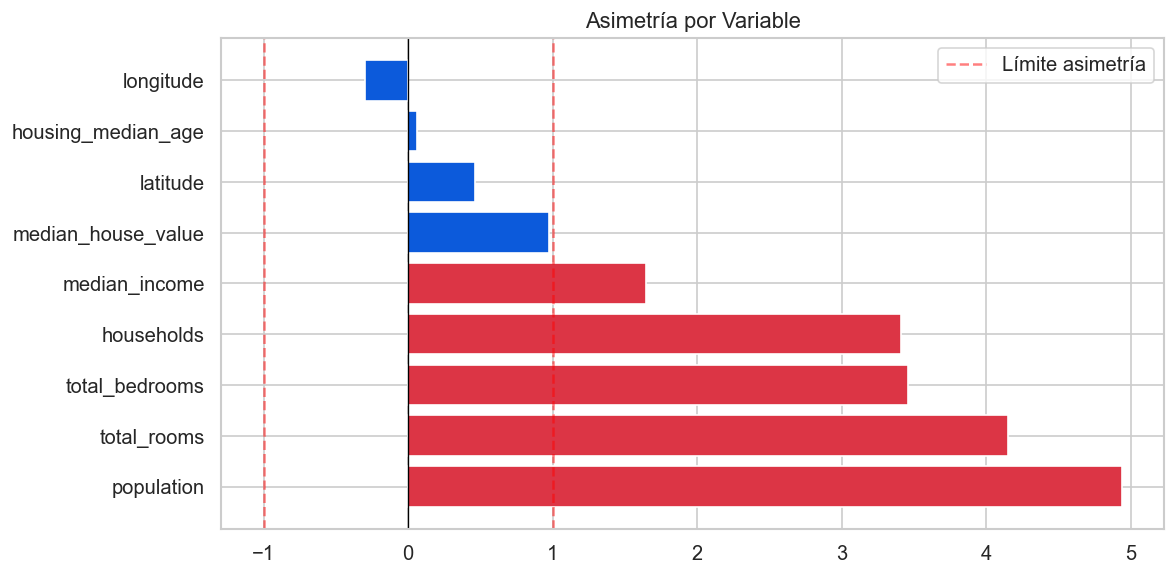

In [22]:
skewness = df.select_dtypes(include=['float64', 'int64']).skew().sort_values(ascending=False)
print("Asimetría (Skewness) de variables numéricas:\n")
for col, val in skewness.items():
    emoji = "⚠️" if abs(val) > 1 else "✅"
    print(f"  {emoji} {col:>25s}: {val:>8.3f}")

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#DC3545' if abs(v) > 1 else '#0C5ADB' for v in skewness.values]
ax.barh(skewness.index, skewness.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(-1, color='red', linestyle='--', alpha=0.5, label='Límite asimetría')
ax.axvline(1, color='red', linestyle='--', alpha=0.5)
ax.set_title('Asimetría por Variable')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Matriz de Correlación
Vamos a visualizar cómo se correlacionan las variables numéricas entre sí y con la variable objetivo.

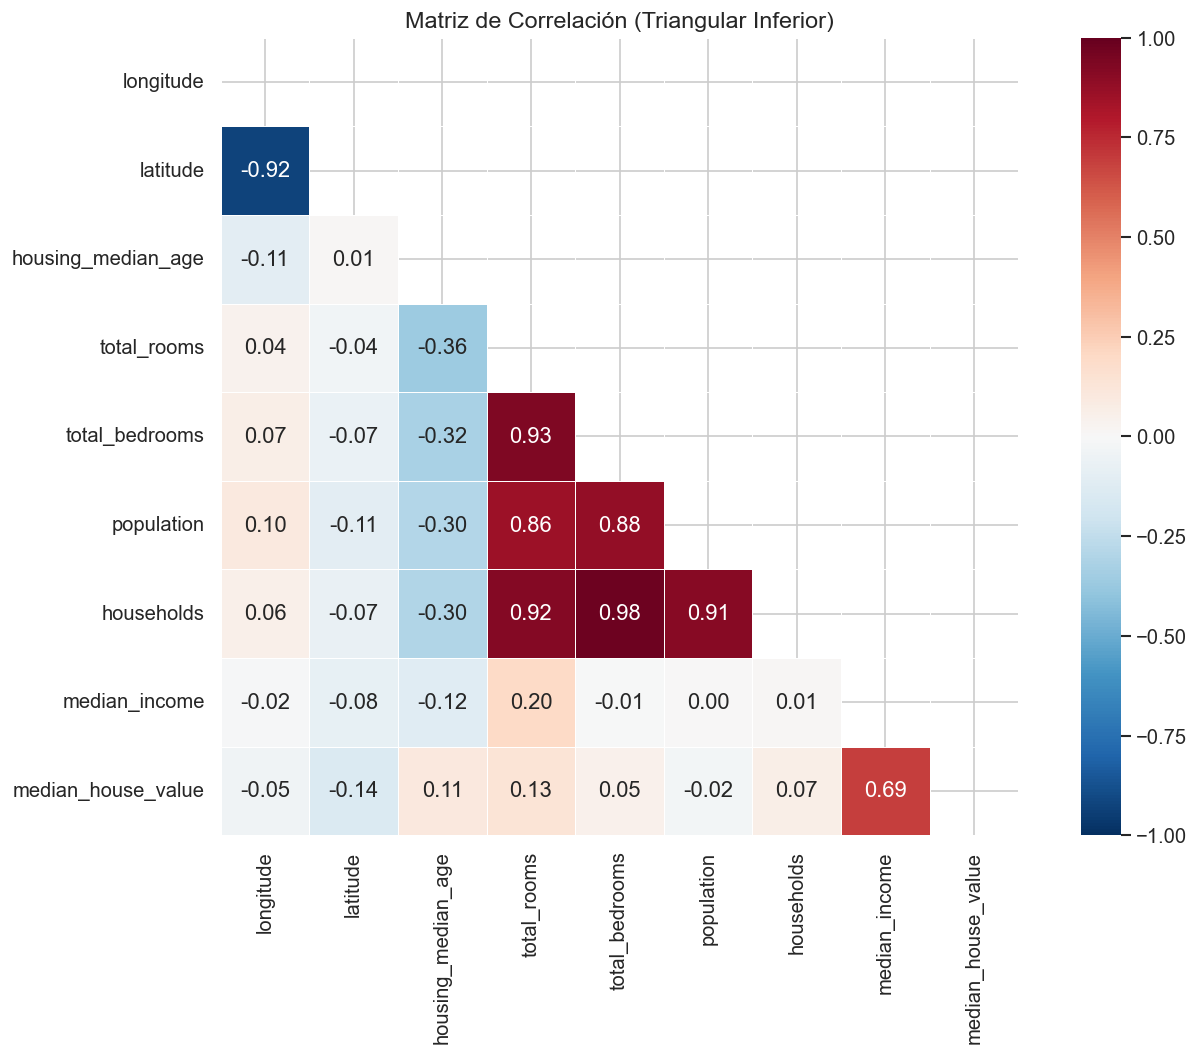


📊 Correlaciones con median_house_value:

  +             median_income:  0.6881  █████████████
  +               total_rooms:  0.1342  ██
  +        housing_median_age:  0.1056  ██
  +                households:  0.0658  █
  +            total_bedrooms:  0.0497  
  -                population: -0.0246  
  -                 longitude: -0.0460  
  -                  latitude: -0.1442  ██


In [23]:
plt.figure(figsize=(12, 9))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()

# Máscara triangular superior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt=".2f",
            mask=mask, vmin=-1, vmax=1, center=0,
            linewidths=0.5, square=True)
plt.title('Matriz de Correlación (Triangular Inferior)', fontsize=14)
plt.tight_layout()
plt.show()

# Correlaciones con la variable objetivo ordenadas
print("\n📊 Correlaciones con median_house_value:\n")
target_corr = corr_matrix['median_house_value'].drop('median_house_value').sort_values(ascending=False)
for col, val in target_corr.items():
    bar = "█" * int(abs(val) * 20)
    sign = "+" if val > 0 else "-"
    print(f"  {sign} {col:>25s}: {val:>7.4f}  {bar}")

## 8. Relación entre Ingreso Medio y Valor de la Vivienda
Basado en la correlación, identificamos el predictor más fuerte del valor de las viviendas.

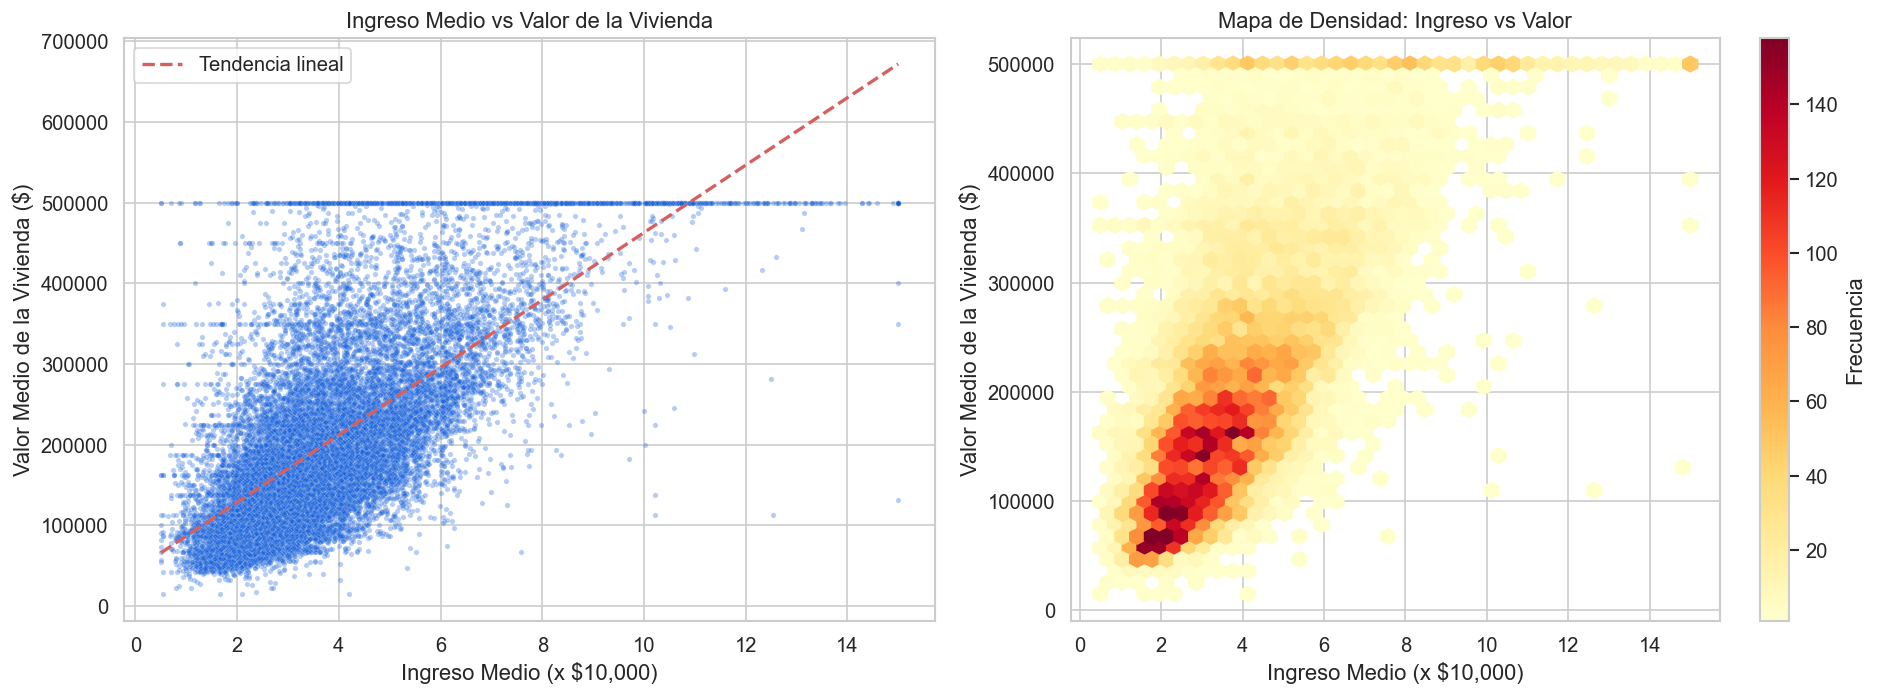

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
sns.scatterplot(x='median_income', y='median_house_value', alpha=0.3,
                color='#0C5ADB', s=10, data=df, ax=axes[0])
# Línea de tendencia
z = np.polyfit(df['median_income'], df['median_house_value'], 1)
p = np.poly1d(z)
x_range = np.linspace(df['median_income'].min(), df['median_income'].max(), 100)
axes[0].plot(x_range, p(x_range), 'r--', linewidth=2, label=f'Tendencia lineal')
axes[0].set_title('Ingreso Medio vs Valor de la Vivienda')
axes[0].set_xlabel('Ingreso Medio (x $10,000)')
axes[0].set_ylabel('Valor Medio de la Vivienda ($)')
axes[0].legend()

# Hexbin (densidad)
hb = axes[1].hexbin(df['median_income'], df['median_house_value'],
                     gridsize=40, cmap='YlOrRd', mincnt=1)
plt.colorbar(hb, ax=axes[1], label='Frecuencia')
axes[1].set_title('Mapa de Densidad: Ingreso vs Valor')
axes[1].set_xlabel('Ingreso Medio (x $10,000)')
axes[1].set_ylabel('Valor Medio de la Vivienda ($)')

plt.tight_layout()
plt.show()

## 9. Análisis por Proximidad al Océano
La variable categórica `ocean_proximity` puede tener un impacto significativo en el valor de las viviendas.

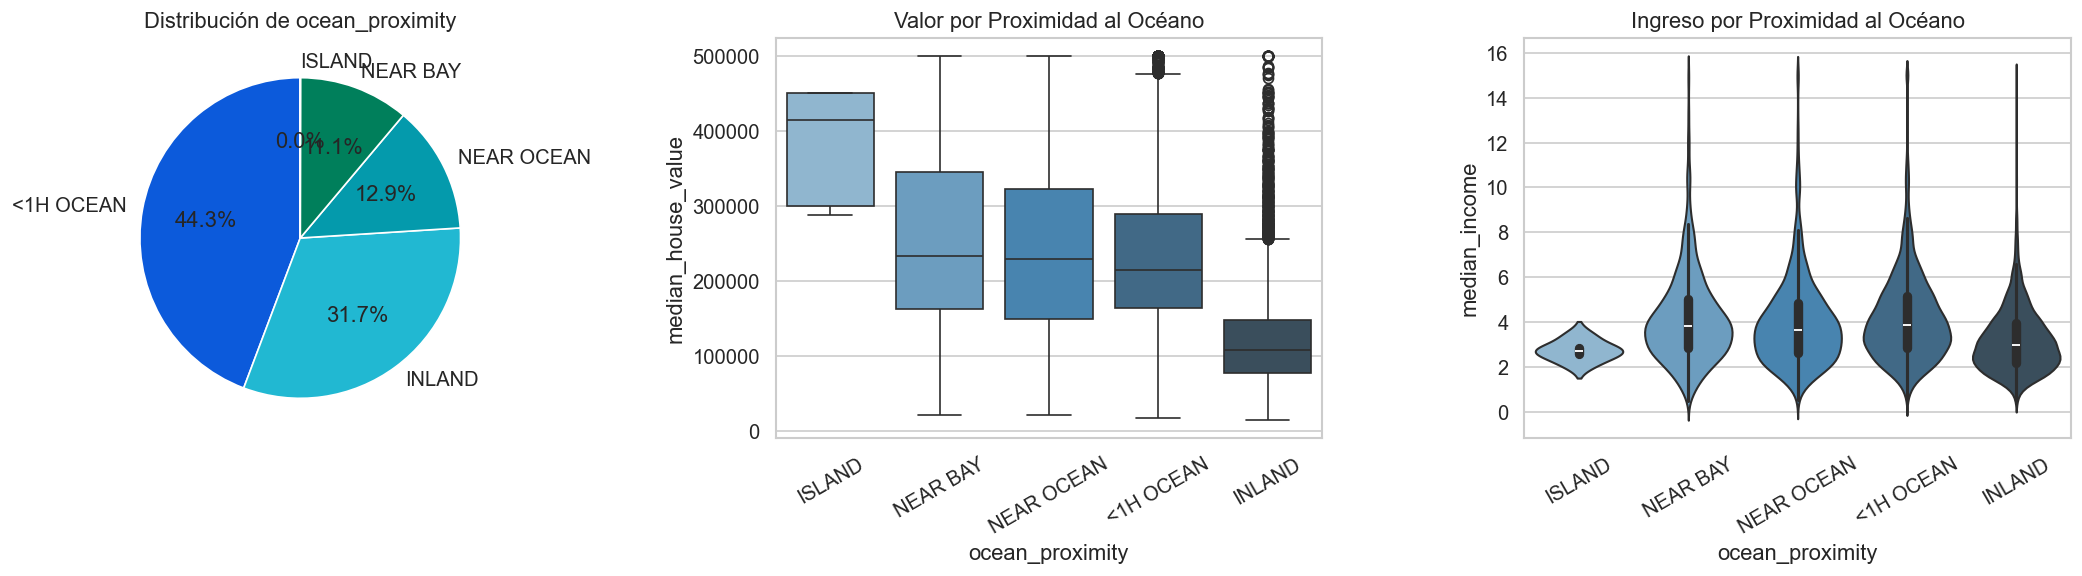


📊 Resumen por Proximidad al Océano:
                    n  valor_medio  valor_mediana  ingreso_medio
ocean_proximity                                                 
ISLAND              5     $380,440       $414,700             $3
NEAR BAY         2290     $259,212       $233,800             $4
NEAR OCEAN       2658     $249,434       $229,450             $4
<1H OCEAN        9136     $240,084       $214,850             $4
INLAND           6551     $124,805       $108,500             $3


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribución de la categoría
ocean_counts = df['ocean_proximity'].value_counts()
colors = ['#0C5ADB', '#21B8D2', '#049AAC', '#007F5B', '#00D084']
axes[0].pie(ocean_counts.values, labels=ocean_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[0].set_title('Distribución de ocean_proximity')

# Boxplot de valor por proximidad
order = df.groupby('ocean_proximity')['median_house_value'].median().sort_values(ascending=False).index
sns.boxplot(x='ocean_proximity', y='median_house_value', data=df,
            order=order, palette='Blues_d', ax=axes[1])
axes[1].set_title('Valor por Proximidad al Océano')
axes[1].tick_params(axis='x', rotation=30)

# Violinplot
sns.violinplot(x='ocean_proximity', y='median_income', data=df,
               order=order, palette='Blues_d', ax=axes[2])
axes[2].set_title('Ingreso por Proximidad al Océano')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Tabla resumen
summary = df.groupby('ocean_proximity').agg(
    n=('median_house_value', 'count'),
    valor_medio=('median_house_value', 'mean'),
    valor_mediana=('median_house_value', 'median'),
    ingreso_medio=('median_income', 'mean'),
).sort_values('valor_medio', ascending=False)
print("\n📊 Resumen por Proximidad al Océano:")
print(summary.to_string(float_format='${:,.0f}'.format))

## 10. Distribución Geográfica
Usamos las coordenadas `latitude` y `longitude` para visualizar la distribución espacial de los datos.

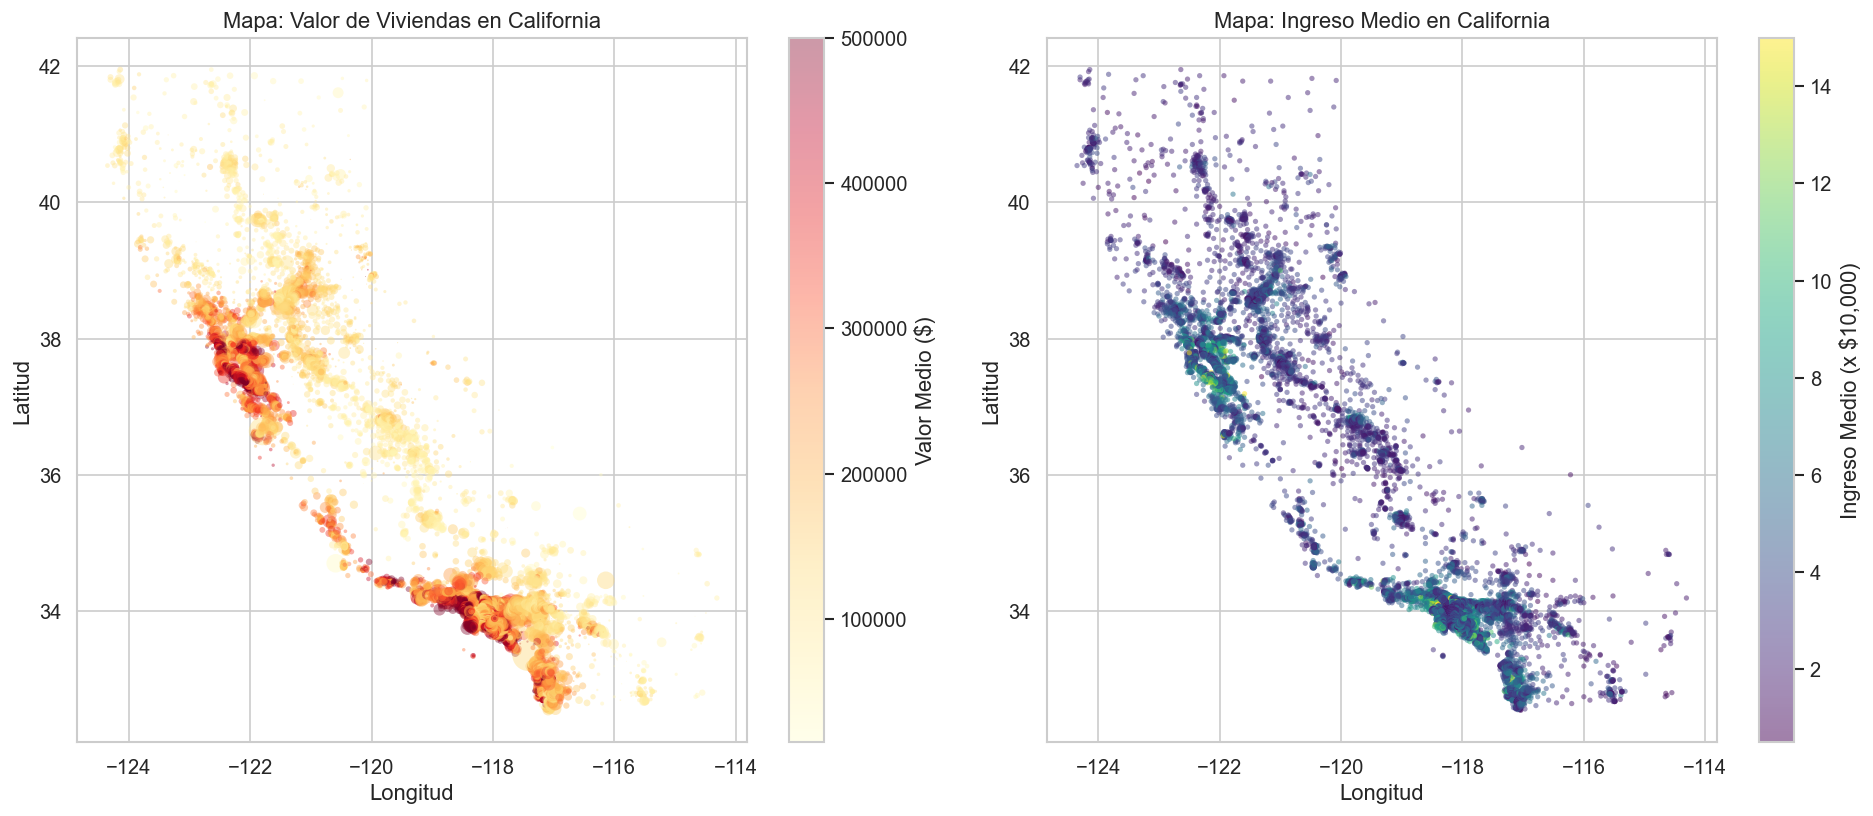

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Mapa de precios
scatter = axes[0].scatter(df['longitude'], df['latitude'],
                          c=df['median_house_value'], cmap='YlOrRd',
                          s=df['population']/100, alpha=0.4, edgecolors='none')
plt.colorbar(scatter, ax=axes[0], label='Valor Medio ($)')
axes[0].set_title('Mapa: Valor de Viviendas en California')
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')

# Mapa de ingreso
scatter2 = axes[1].scatter(df['longitude'], df['latitude'],
                           c=df['median_income'], cmap='viridis',
                           s=10, alpha=0.5, edgecolors='none')
plt.colorbar(scatter2, ax=axes[1], label='Ingreso Medio (x $10,000)')
axes[1].set_title('Mapa: Ingreso Medio en California')
axes[1].set_xlabel('Longitud')
axes[1].set_ylabel('Latitud')

plt.tight_layout()
plt.show()

## 11. Detección de Outliers con IQR
Identificamos valores atípicos utilizando el método del Rango Intercuartílico (IQR).

📊 Detección de Outliers (Método IQR):

          Variable  Outliers  % del Total  Límite Inf.  Límite Sup.
       total_rooms      1287         6.24     -1102.62      5698.38
    total_bedrooms      1271         6.16      -230.50      1173.50
        households      1220         5.91      -207.50      1092.50
        population      1196         5.79      -620.00      3132.00
median_house_value      1071         5.19    -98087.50    482412.50
     median_income       681         3.30        -0.71         8.01
         longitude         0         0.00      -127.48      -112.33
          latitude         0         0.00        28.26        43.38
housing_median_age         0         0.00       -10.50        65.50


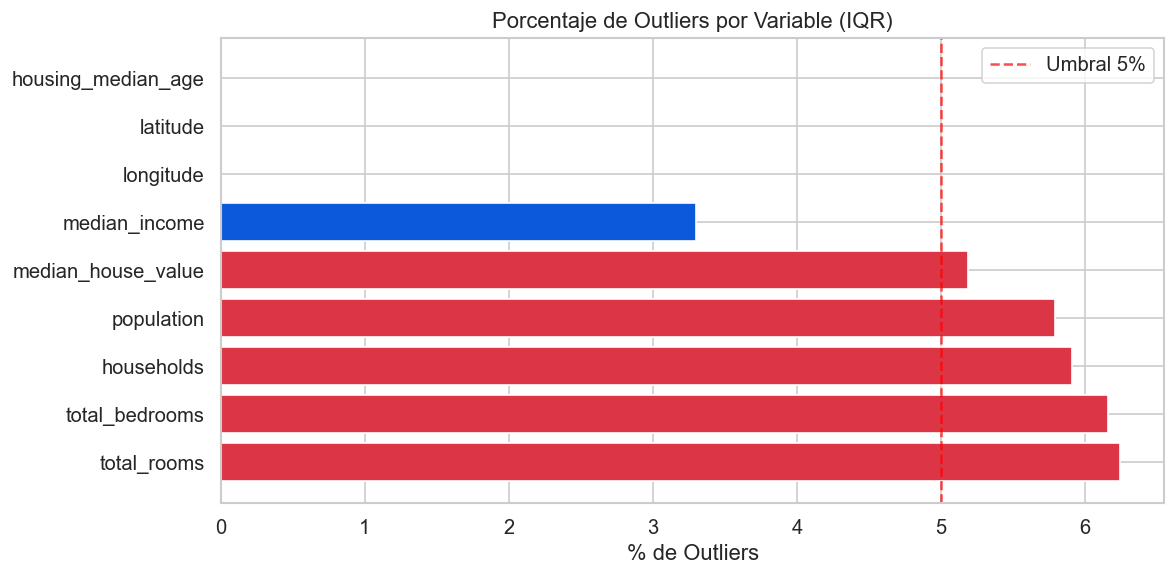

In [27]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
outlier_info = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_outliers / len(df) * 100
    outlier_info.append({'Variable': col, 'Outliers': n_outliers, '% del Total': round(pct, 2),
                         'Límite Inf.': round(lower, 2), 'Límite Sup.': round(upper, 2)})

outlier_df = pd.DataFrame(outlier_info).sort_values('Outliers', ascending=False)
print("📊 Detección de Outliers (Método IQR):\n")
print(outlier_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#DC3545' if v > 5 else '#0C5ADB' for v in outlier_df['% del Total']]
ax.barh(outlier_df['Variable'], outlier_df['% del Total'], color=colors)
ax.set_xlabel('% de Outliers')
ax.set_title('Porcentaje de Outliers por Variable (IQR)')
ax.axvline(5, color='red', linestyle='--', alpha=0.7, label='Umbral 5%')
ax.legend()
plt.tight_layout()
plt.show()

## 12. Features Derivadas (Feature Engineering)
Creamos nuevas variables que pueden mejorar la capacidad predictiva de los modelos.

📊 Correlación de features derivadas con median_house_value:

             rooms_per_household:  0.1519  ████
               bedrooms_per_room: -0.2559  ███████
        population_per_household: -0.0237  


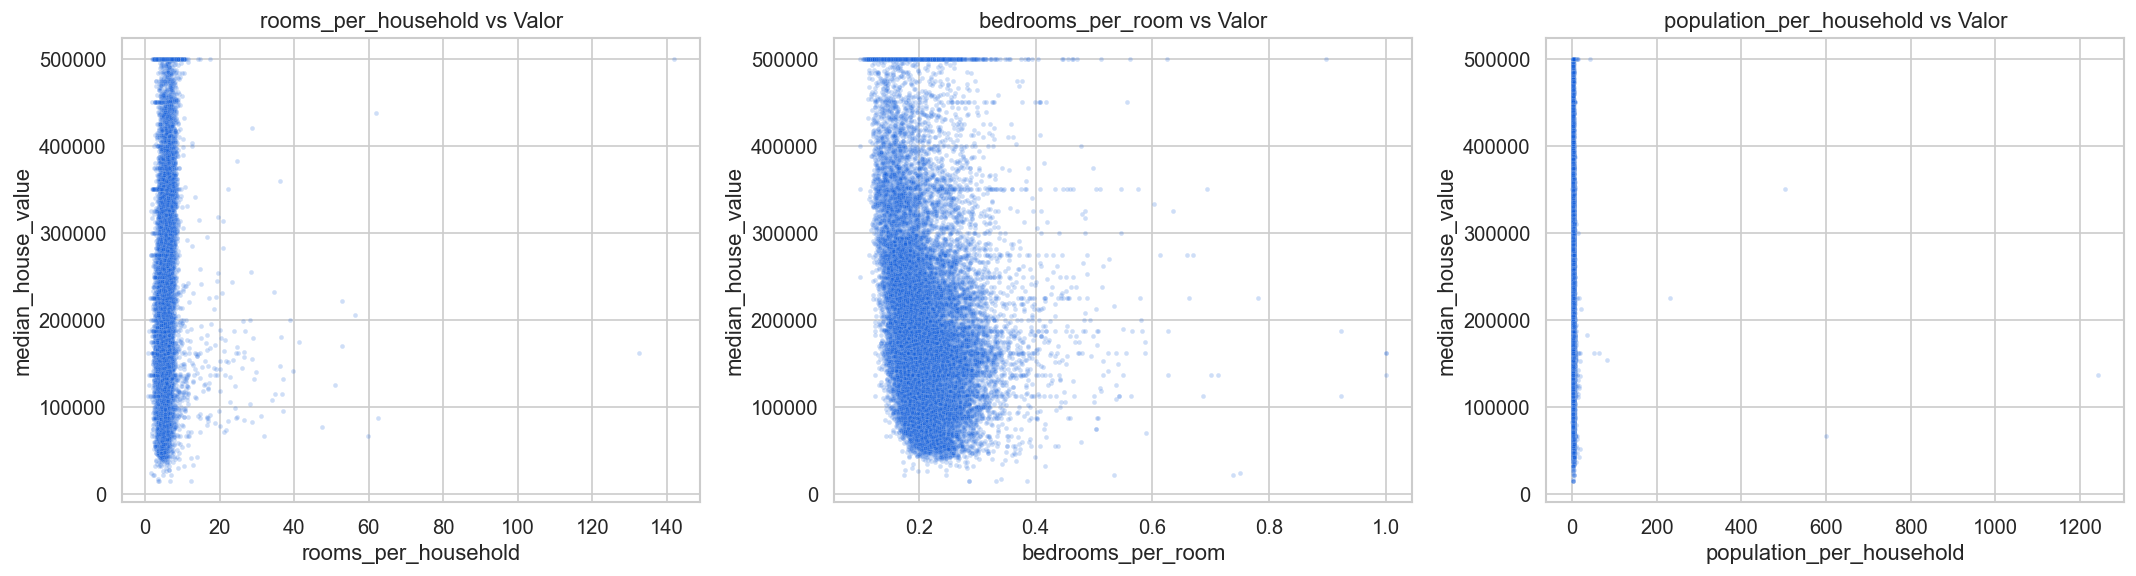

In [28]:
# Crear features derivadas
df_feat = df.copy()
df_feat['rooms_per_household'] = df_feat['total_rooms'] / df_feat['households']
df_feat['bedrooms_per_room'] = df_feat['total_bedrooms'] / df_feat['total_rooms']
df_feat['population_per_household'] = df_feat['population'] / df_feat['households']

# Correlación de features derivadas con el target
new_features = ['rooms_per_household', 'bedrooms_per_room', 'population_per_household']
print("📊 Correlación de features derivadas con median_house_value:\n")
for feat in new_features:
    corr = df_feat[feat].corr(df_feat['median_house_value'])
    bar = "█" * int(abs(corr) * 30)
    print(f"  {feat:>30s}: {corr:>7.4f}  {bar}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(new_features):
    sns.scatterplot(x=feat, y='median_house_value', data=df_feat,
                    alpha=0.2, s=8, color='#0C5ADB', ax=axes[i])
    axes[i].set_title(f'{feat} vs Valor')

plt.tight_layout()
plt.show()

## 13. Conclusiones del EDA
Hallazgos clave que guiarán el modelado.

In [29]:
# Calcular conclusiones dinámicamente desde los datos
target = 'median_house_value'
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_with_target = numeric_df.corr()[target].drop(target).sort_values(ascending=False)
best_predictor = corr_with_target.index[0]
best_corr = corr_with_target.iloc[0]

null_col = df.isnull().sum()
null_col = null_col[null_col > 0]

techo_count = (df[target] == df[target].max()).sum()
techo_pct = techo_count / len(df) * 100

skewed_vars = numeric_df.skew()
strongly_skewed = skewed_vars[skewed_vars.abs() > 1].index.tolist()

df_feat_tmp = df.copy()
df_feat_tmp['bedrooms_per_room'] = df_feat_tmp['total_bedrooms'] / df_feat_tmp['total_rooms']
bpr_corr = df_feat_tmp['bedrooms_per_room'].corr(df_feat_tmp[target])

ocean_medians = df.groupby('ocean_proximity')[target].median().sort_values(ascending=False)
best_location = ocean_medians.index[0]

outlier_pct = {}
for col in numeric_df.columns:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_pct[col] = n_out / len(df) * 100
high_outlier_vars = [k for k, v in outlier_pct.items() if v > 5]

print("=" * 70)
print("         CONCLUSIONES DEL ANÁLISIS EXPLORATORIO")
print("=" * 70)

print(f"\n  🔑 Predictor principal")
print(f"    → {best_predictor} tiene la correlación más alta (r = {best_corr:.4f}) con {target}")

print(f"\n  ⚠️ Datos truncados")
print(f"    → {target} tiene {techo_count:,} valores ({techo_pct:.1f}%) en el techo de ${df[target].max():,.0f}")

print(f"\n  🏖️ Ubicación importa")
print(f"    → Las viviendas en '{best_location}' tienen la mediana más alta (${ocean_medians.iloc[0]:,.0f})")

print(f"\n  📐 Asimetría")
if strongly_skewed:
    print(f"    → Variables con fuerte asimetría (|skew| > 1): {', '.join(strongly_skewed)}")
else:
    print(f"    → No hay variables con asimetría fuerte")

print(f"\n  🔧 Valores nulos")
if len(null_col) > 0:
    for col_name, n_nulls in null_col.items():
        print(f"    → {col_name}: {n_nulls:,} nulos ({n_nulls/len(df)*100:.1f}%) — se imputarán con la mediana")
else:
    print(f"    → No hay valores nulos en el dataset")

print(f"\n  📊 Feature Engineering")
print(f"    → bedrooms_per_room tiene correlación {bpr_corr:.4f} con {target}")

print(f"\n  🌍 Geografía")
print(f"    → latitude y longitude capturan patrones espaciales del dataset")

print(f"\n  📏 Outliers")
if high_outlier_vars:
    print(f"    → Variables con >5% outliers (IQR): {', '.join(high_outlier_vars)}")
else:
    print(f"    → Ninguna variable supera el 5% de outliers")

print(f"\n  📋 Dataset")
print(f"    → {df.shape[0]:,} registros x {df.shape[1]} columnas")
print(f"    → {len(numeric_df.columns)} numéricas + {len(df.select_dtypes(include='object').columns)} categórica(s)")

print("\n" + "=" * 70)

         CONCLUSIONES DEL ANÁLISIS EXPLORATORIO

  🔑 Predictor principal
    → median_income tiene la correlación más alta (r = 0.6881) con median_house_value

  ⚠️ Datos truncados
    → median_house_value tiene 965 valores (4.7%) en el techo de $500,001

  🏖️ Ubicación importa
    → Las viviendas en 'ISLAND' tienen la mediana más alta ($414,700)

  📐 Asimetría
    → Variables con fuerte asimetría (|skew| > 1): total_rooms, total_bedrooms, population, households, median_income

  🔧 Valores nulos
    → total_bedrooms: 207 nulos (1.0%) — se imputarán con la mediana

  📊 Feature Engineering
    → bedrooms_per_room tiene correlación -0.2559 con median_house_value

  🌍 Geografía
    → latitude y longitude capturan patrones espaciales del dataset

  📏 Outliers
    → Variables con >5% outliers (IQR): total_rooms, total_bedrooms, population, households, median_house_value

  📋 Dataset
    → 20,640 registros x 10 columnas
    → 9 numéricas + 1 categórica(s)

